# Import dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.preprocessing import StandardScaler
from  sklearn.linear_model import Lasso


# Data Collection

In [3]:
car_dataset = pd.read_csv('/content/extracted_files/car data.csv')

# Data Preprocessing

In [4]:
#printing the first 5 rows of the dataset
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
#printing the last 5 rows of the dataset
car_dataset.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [6]:
# Checking the number of datapoints
car_dataset.shape

(301, 9)

In [8]:
#Checking for the datapoints information
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
#Specific function for finding missing values
car_dataset.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [10]:
#checking the distribution of categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


# Encoding

In [19]:
# encoding the categorical data to numerical values
#Fuel Type  column encoding
car_dataset['Fuel_Type'] = car_dataset['Fuel_Type'].replace({"Petrol" : 0 , "Diesel" : 1 , "CNG" : 2})
#Seller Type column encoding
car_dataset['Seller_Type'] = car_dataset['Seller_Type'].replace({"Dealer" : 0 , "Individual" : 1 })
#Transmission column encoding
car_dataset['Transmission'] = car_dataset['Transmission'].replace({"Manual" : 0 , "Automatic" : 1 })

In [20]:
#checking the update dataset
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


#Spliting the data to Feature and Target Variables

In [21]:
# Feature variables
X = car_dataset.drop(['Car_Name' , 'Selling_Price'] , axis=1)

In [23]:
# Target variables
y = car_dataset['Selling_Price']

In [24]:
#printing the feature
print(X)

     Year  Present_Price  Kms_Driven  ...  Seller_Type  Transmission  Owner
0    2014           5.59       27000  ...            0             0      0
1    2013           9.54       43000  ...            0             0      0
2    2017           9.85        6900  ...            0             0      0
3    2011           4.15        5200  ...            0             0      0
4    2014           6.87       42450  ...            0             0      0
..    ...            ...         ...  ...          ...           ...    ...
296  2016          11.60       33988  ...            0             0      0
297  2015           5.90       60000  ...            0             0      0
298  2009          11.00       87934  ...            0             0      0
299  2017          12.50        9000  ...            0             0      0
300  2016           5.90        5464  ...            0             0      0

[301 rows x 7 columns]


In [25]:
#printing target
print(y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


# Splitting the data to traininga nd testing data

In [30]:
#Splitting the dataset
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.3, random_state=42)

In [31]:
#Printing the shape of X
print(X.shape)

(301, 7)


In [32]:
#printing the shape of X.train
print(X_train.shape)

(210, 7)


In [33]:
#printing the shape of X.test
print(X_test.shape)

(91, 7)


#Model Creation

In [35]:
# Loading the imported model
LR_model = LinearRegression()

In [36]:
# Fitting the data to model
LR_model.fit(X_train , y_train)

LinearRegression()

# Evaulation of Linear Model

#### Prediction on training data

In [42]:
training_data_prediction = LR_model.predict(X_train)
print(f"The r2_score: {metrics.r2_score(y_train, training_data_prediction)}")
print(f"The mean squared error: {metrics.mean_squared_error(y_train , training_data_prediction)}")

The r2_score: 0.8761249192923499
The mean squared error: 3.0402210377501486


### Visyualize the actual and predicated price

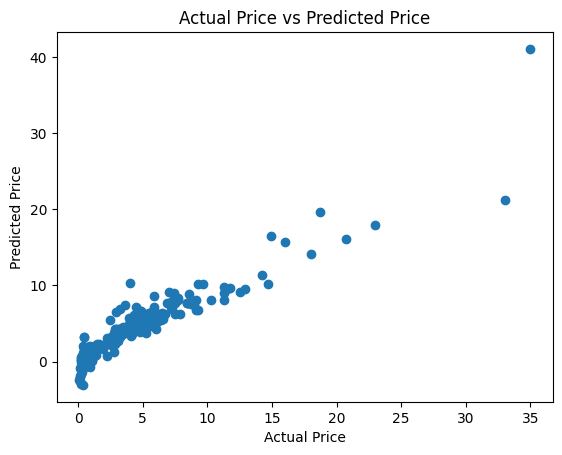

In [43]:
plt.scatter(y_train , training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

In [46]:
#prediction on testing data
testing_data_prediction = LR_model.predict(X_test)
print(f"The r2_score: {metrics.r2_score(y_test, testing_data_prediction)}")
print(f"The mean squared error: {metrics.mean_squared_error(y_test, testing_data_prediction)}")

The r2_score: 0.8773175030338082
The mean squared error: 3.4932860262264396


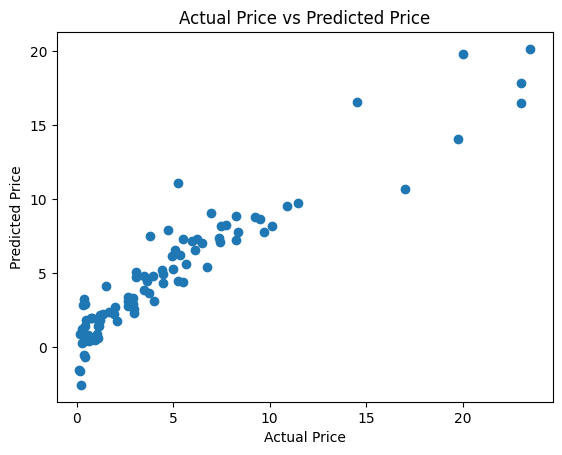

In [49]:
plt.scatter(y_test , testing_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

#2.  Lasso Regression

# Model Creation

In [52]:
# Loading the imported model
lasso_model = Lasso()

In [54]:
# Fitting the data to model
lasso_model.fit(X_train , y_train)

Lasso()

# Model Evalution

# Evalution on training dataset

In [58]:
# Prediction on Training data
training_data_prediction = lasso_model.predict(X_train)
print(f"The r2_score: {metrics.r2_score(y_train, training_data_prediction)}")
print(f"The mean squared error: {metrics.mean_squared_error(y_train , training_data_prediction)}")

The r2_score: 0.8356651722276249
The mean squared error: 4.033209889951397


### Visualize the actual and predicated price

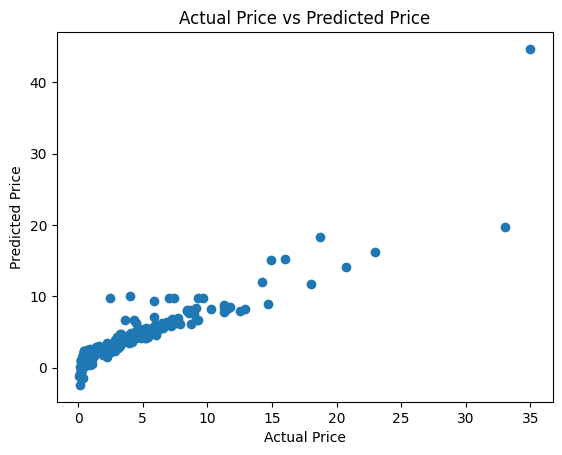

In [59]:
plt.scatter(y_train , training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

# Evalution on testing  dataset

In [61]:
#prediction on testing data
testing_data_prediction = lasso_model.predict(X_test)
print(f"The r2_score: {metrics.r2_score(y_test, testing_data_prediction)}")
print(f"The mean squared error: {metrics.mean_squared_error(y_test, testing_data_prediction)}")

The r2_score: 0.8396199056735947
The mean squared error: 4.5666949748316705


###Visualize the actual and predicated price

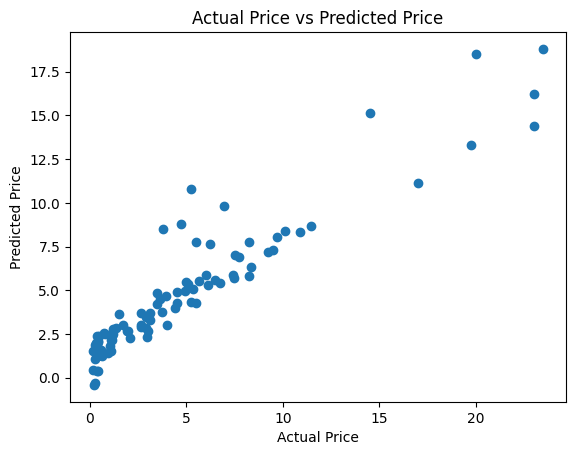

In [62]:
plt.scatter(y_test , testing_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()